<a href="https://colab.research.google.com/github/nurcoz/Udemy_time_series/blob/main/Introduction_to_Time_Series_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup

In [1]:
# Mount the drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Python - Time Series Forecasting/Time Series Analysis/Introduction to Time Series Forecasting

/content/drive/MyDrive/Python - Time Series Forecasting/Time Series Analysis/Introduction to Time Series Forecasting


In [3]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
# Load the dataset
df = pd.read_csv('bitcoin_price.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


## Time Series Index

In [7]:
# Convert "Date" variable to a datetime object with the right format YYYY-MM-DD or "%Y-%m-%d"
# Kafa karışıklığı olmaması için önemli bir adım
df["Date"] = pd.to_datetime(df["Date"], format = "%Y-%m-%d")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [8]:
# Set Date as index
# Kolon olarak da eklememiz lazım- bunu indexle yapıyoruz
df.set_index("Date", inplace=True)
# Aşağıda tabloda görüldüğü gibi zaman serisi olarak aldık Date değişkenini
df.head()


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [9]:
# Veri setinde spesifik bir tarih seçmek için (index üzerinden gitmek için)
# Aşağıda görüldüğü gibi belirli bir satır için tüm değerleri aldı
df.loc['2021-11-09']

,2021-11-09
Open,6.754973e+04
High,6.853034e+04
Low,6.638206e+04
Close,6.697183e+04
Adj Close,6.697183e+04
Volume,4.235799e+10


In [10]:
# Set the index when we import the data
# Index sütununu tarihe eşitliyoruz
# Verileri içe aktarırken indeksi ayarlayabiliriz.
df1 = pd.read_csv("bitcoin_price.csv", index_col= "Date", parse_dates=True)
df1.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [15]:
# Resample data to a different time granularity
# Haftalık resample ediyoruz bu yüzden W dedik
df.resample('W').mean()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-21,429.916998,437.718195,406.624402,416.859003,416.859003,3.138068e+07
2014-09-28,410.650718,418.668993,399.377141,407.692566,407.692566,2.668180e+07
2014-10-05,369.774288,376.721000,353.207140,361.426570,361.426570,3.952256e+07
2014-10-12,346.927429,363.308864,337.567858,355.234580,355.234580,4.873611e+07
2014-10-19,389.010284,397.790427,380.410575,390.479854,390.479854,2.241458e+07
...,...,...,...,...,...,...
2023-12-03,38038.414062,38743.479353,37766.444196,38399.994978,38399.994978,1.919430e+10
2023-12-10,43002.227121,44027.167411,42586.383929,43538.877232,43538.877232,2.692909e+10
2023-12-17,42369.368862,42969.940848,41148.103237,42020.472656,42020.472656,2.407050e+10


## Exploratory Data Analysis

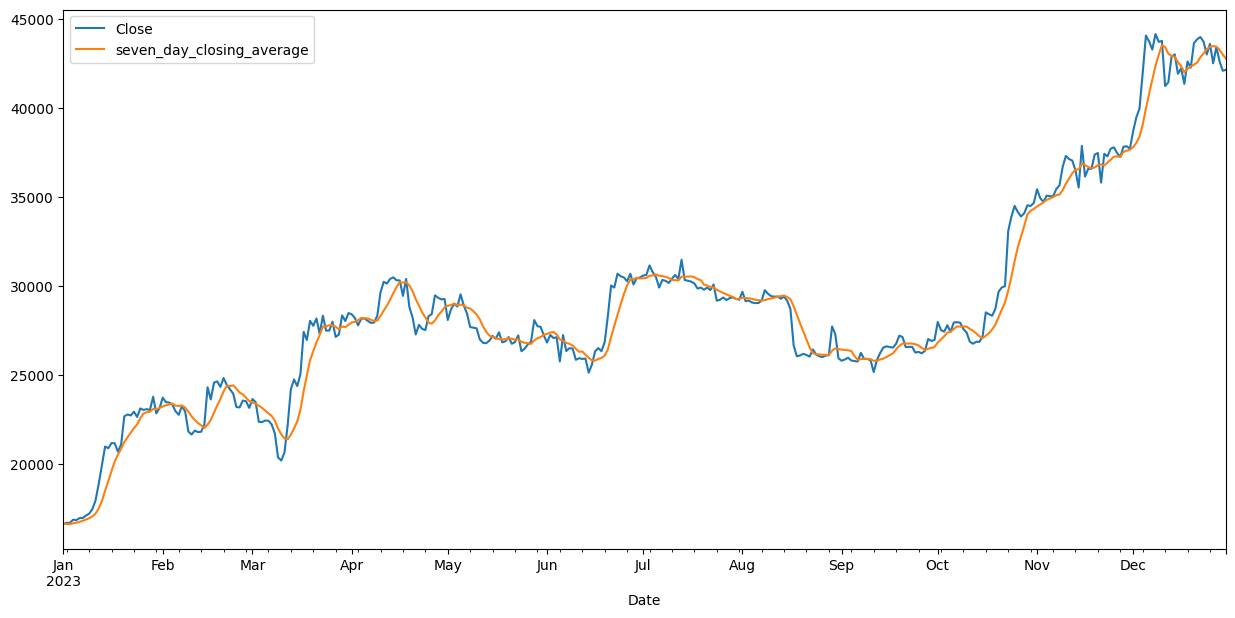

In [24]:
# Generate 7 day rolling average for closing price
df['seven_day_closing_average'] = df['Close'].rolling(7).mean()
df[['Close', 'seven_day_closing_average']].loc['2023'].plot(figsize=(15,7))
plt.show()

In [27]:
# Find the month with a highest closing average
df.resample('ME').max()['Close'].idxmax()

Timestamp('2021-11-30 00:00:00')

In [28]:
# Preview the last 5 rows of the dataset
df.tail()

,Open,High,Low,Close,Adj Close,Volume,seven_day_closing_average
Date,,,,,,,
2023-12-26,43599.847656,43603.175781,41676.488281,42520.402344,42520.402344,30026850982,43486.929688
2023-12-27,42518.468750,43683.160156,42167.582031,43442.855469,43442.855469,25260941032,43457.016183
2023-12-28,43468.199219,43804.781250,42318.550781,42627.855469,42627.855469,22992093014,43279.688058
2023-12-29,42614.644531,43124.324219,41424.062500,42099.402344,42099.402344,26000021055,43008.473772
2023-12-30,42091.753906,42584.125000,41556.226562,42156.902344,42156.902344,16013925945,42782.382254
